# Blocco 4 — Instance Graph su una process execution reale

## Obiettivo

Costruire e analizzare un **Instance Graph** a partire da una process
execution estratta dal dataset reale **Order Management** in formato
OCEL 2.0.

Il blocco utilizza come leading object l'ordine `o-990424` e conserva
gli eventi collegati agli oggetti rilevanti dell'ordine.

L'obiettivo è verificare:

- quali eventi appartengono all'esecuzione;
- quali relazioni causali vengono rappresentate;
- se il grafo è un DAG;
- se il grafo è transitivamente ridotto;
- quali eventi risultano incomparabili e quindi potenzialmente paralleli.

> **Limite metodologico:** le causal relations utilizzate in questo
> blocco sono definite manualmente. Non sono ancora derivate
> automaticamente dall'Object-Centric Petri Net.

## 1. Caricamento delle dipendenze

Il notebook riutilizza le funzioni implementate nel package
`ocpm_partial_order`.

In questo modo la logica di estrazione e costruzione del grafo resta
nel codice sorgente testabile, mentre il notebook documenta e rende
riproducibile l'esperimento.

In [1]:
from pathlib import Path

import networkx as nx
import pandas as pd

from IPython.display import Image, display

from ocpm_partial_order.config import MAIN_DATASET_DB
from ocpm_partial_order.extraction import (
    extract_order_centred_execution,
)
from ocpm_partial_order.graphs.concurrency import (
    find_incomparable_event_pairs,
)
from ocpm_partial_order.graphs.instance_graph import (
    build_instance_graph,
)
from ocpm_partial_order.io.ocel_loader import (
    load_ocel2_sqlite,
)
from ocpm_partial_order.io.sample_loader import (
    load_causal_relations,
)
from ocpm_partial_order.visualization.graph_visualizer import (
    save_instance_graph,
)


PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

ORDER_ID = "o-990424"

RELATIONS_PATH = (
    PROJECT_ROOT
    / "data"
    / "derived"
    / "order_management_o_990424_causal_relations.json"
)

GRAPH_OUTPUT_PATH = (
    PROJECT_ROOT
    / "outputs"
    / "graphs"
    / "order_management_o_990424_instance_graph.png"
)

print("Dataset:", MAIN_DATASET_DB)
print("Ordine selezionato:", ORDER_ID)
print("Causal relations:", RELATIONS_PATH)

Dataset: C:\Users\nicol\ocpm-partial-order\ocpm-partial-order\data\raw\order_management.sqlite
Ordine selezionato: o-990424
Causal relations: C:\Users\nicol\ocpm-partial-order\ocpm-partial-order\data\derived\order_management_o_990424_causal_relations.json


## 2. Estrazione order-centred

L'uso indiscriminato di tutte le connected components del dataset
Order Management può produrre un'unica esecuzione molto grande.

Oggetti riutilizzati, come `employees` e `products`, possono infatti
agire da ponti tra ordini differenti.

Per questo esperimento viene adottato un criterio **order-centred**:

1. si seleziona un ordine come leading object;
2. si individuano gli item collegati all'ordine;
3. si individuano i package collegati a tali item;
4. si mantengono gli eventi relativi a questa porzione del processo.

La scelta non converte il log in una semplice traccia sequenziale:
gli eventi mantengono i riferimenti agli oggetti coinvolti.

In [2]:
ocel = load_ocel2_sqlite(MAIN_DATASET_DB)

execution = extract_order_centred_execution(
    ocel=ocel,
    order_id=ORDER_ID,
)

print("Process execution estratta")
print("Ordine:", ORDER_ID)
print("Numero di eventi:", len(execution.events))

Process execution estratta
Ordine: o-990424
Numero di eventi: 7


## 3. Causal relations del prototipo

Il file seguente contiene sei relazioni tra coppie di attività.

Ogni relazione specifica:

- attività sorgente;
- attività destinazione;
- tipo di oggetto che giustifica il collegamento.

Queste relazioni rappresentano un'ipotesi causale esplicita del
prototipo. Il timestamp, da solo, non viene considerato una prova di
causalità.

In [3]:
causal_relations = load_causal_relations(
    RELATIONS_PATH
)

relations_table = pd.read_json(RELATIONS_PATH)

display(relations_table)

print(
    "Numero di causal relations:",
    len(causal_relations),
)

,source_activity,target_activity,object_type
0,place order,confirm order,orders
1,confirm order,pay order,orders
2,place order,pick item,items
3,pick item,create package,items
4,create package,send package,packages
5,send package,package delivered,packages


Numero di causal relations: 6


## 4. Costruzione dell'Instance Graph

Ogni evento della process execution diventa un nodo.

Un arco viene aggiunto quando:

1. le attività della coppia corrispondono a una causal relation;
2. i due eventi condividono almeno un oggetto del tipo richiesto;
3. la relazione rispetta la direzione causale specificata.

Al termine vengono eliminati gli archi transitivi ridondanti,
preservando la raggiungibilità tra gli eventi.

In [4]:
graph = build_instance_graph(
    execution=execution,
    causal_relations=causal_relations,
)

print("Nodi:", graph.number_of_nodes())
print("Archi:", graph.number_of_edges())
print(
    "DAG:",
    nx.is_directed_acyclic_graph(graph),
)

Nodi: 7
Archi: 6
DAG: True


## 5. Eventi dell'esecuzione

Gli eventi vengono ordinati cronologicamente soltanto per facilitarne
la lettura.

L'ordine temporale della tabella non introduce automaticamente archi
nel grafo.

In [5]:
event_rows = []

for node_id, attributes in graph.nodes(data=True):
    event_rows.append(
        {
            "event_id": node_id,
            "activity": attributes["activity"],
            "timestamp": attributes["timestamp"],
        }
    )

events_table = (
    pd.DataFrame(event_rows)
    .sort_values(
        ["timestamp", "event_id"],
        ignore_index=True,
    )
)

display(events_table)

,event_id,activity,timestamp
0,place_o-990424,place order,2023-06-30 07:17:18+00:00
1,confirm_o-990424,confirm order,2023-06-30 09:34:37+00:00
2,pick_i-881734,pick item,2023-07-04 09:43:05+00:00
3,create_p-660247,create package,2023-07-06 13:32:41+00:00
4,send_p-660247,send package,2023-07-10 11:59:43+00:00
5,deliver_p-660247,package delivered,2023-07-11 09:46:09+00:00
6,pay_o-990424,pay order,2023-07-26 12:22:06+00:00


## 6. Archi causali e oggetti condivisi

Gli attributi degli archi permettono di controllare quale tipo e quale
identificativo di oggetto sostengono ogni relazione.

Il ramo dell'ordine contiene `confirm order` e `pay order`; il ramo
logistico attraversa item e package fino a `package delivered`.

In [6]:
edge_rows = []

for source, target, attributes in graph.edges(data=True):
    edge_rows.append(
        {
            "source": source,
            "target": target,
            "object_types": ", ".join(
                sorted(attributes["object_types"])
            ),
            "object_ids": ", ".join(
                sorted(attributes["object_ids"])
            ),
        }
    )

edges_table = (
    pd.DataFrame(edge_rows)
    .sort_values(
        ["source", "target"],
        ignore_index=True,
    )
)

display(edges_table)

,source,target,object_types,object_ids
0,confirm_o-990424,pay_o-990424,orders,o-990424
1,create_p-660247,send_p-660247,packages,p-660247
2,pick_i-881734,create_p-660247,items,i-881734
3,place_o-990424,confirm_o-990424,orders,o-990424
4,place_o-990424,pick_i-881734,items,i-881734
5,send_p-660247,deliver_p-660247,packages,p-660247


## 7. Verifica strutturale

Il risultato atteso contiene sette nodi e sei archi.

Il grafo deve inoltre essere:

- diretto;
- aciclico;
- già transitivamente ridotto.

La riduzione transitiva elimina un arco diretto quando esiste già un
cammino alternativo tra gli stessi nodi. La raggiungibilità causale
rimane invariata.

In [7]:
EXPECTED_NODES = {
    "place_o-990424",
    "confirm_o-990424",
    "pay_o-990424",
    "pick_i-881734",
    "create_p-660247",
    "send_p-660247",
    "deliver_p-660247",
}

EXPECTED_EDGES = {
    (
        "place_o-990424",
        "confirm_o-990424",
    ),
    (
        "confirm_o-990424",
        "pay_o-990424",
    ),
    (
        "place_o-990424",
        "pick_i-881734",
    ),
    (
        "pick_i-881734",
        "create_p-660247",
    ),
    (
        "create_p-660247",
        "send_p-660247",
    ),
    (
        "send_p-660247",
        "deliver_p-660247",
    ),
}

assert set(graph.nodes) == EXPECTED_NODES
assert set(graph.edges) == EXPECTED_EDGES
assert nx.is_directed_acyclic_graph(graph)

reduced_graph = nx.transitive_reduction(graph)

assert set(reduced_graph.nodes) == set(graph.nodes)
assert set(reduced_graph.edges) == set(graph.edges)

original_closure = nx.transitive_closure_dag(graph)
reduced_closure = nx.transitive_closure_dag(
    reduced_graph
)

assert set(original_closure.edges) == set(
    reduced_closure.edges
)

print("Verifica strutturale superata")
print("- 7 nodi")
print("- 6 archi")
print("- DAG")
print("- riduzione transitiva verificata")

Verifica strutturale superata
- 7 nodi
- 6 archi
- DAG
- riduzione transitiva verificata


## 8. Eventi incomparabili

Due eventi sono incomparabili quando nel grafo non esiste:

- né un cammino dal primo al secondo;
- né un cammino dal secondo al primo.

L'incomparabilità indica che il grafo non impone un ordine causale tra
i due eventi. Nel prototipo viene quindi interpretata come
**parallelismo potenziale**, non come prova definitiva di esecuzione
simultanea.

In [8]:
incomparable_pairs = (
    find_incomparable_event_pairs(graph)
)

incomparable_rows = []

for first, second in sorted(incomparable_pairs):
    incomparable_rows.append(
        {
            "first_event": first,
            "first_activity": (
                graph.nodes[first]["activity"]
            ),
            "second_event": second,
            "second_activity": (
                graph.nodes[second]["activity"]
            ),
        }
    )

incomparable_table = pd.DataFrame(
    incomparable_rows
)

display(incomparable_table)

print(
    "Numero di coppie incomparabili:",
    len(incomparable_pairs),
)

,first_event,first_activity,second_event,second_activity
0,confirm_o-990424,confirm order,create_p-660247,create package
1,confirm_o-990424,confirm order,deliver_p-660247,package delivered
2,confirm_o-990424,confirm order,pick_i-881734,pick item
3,confirm_o-990424,confirm order,send_p-660247,send package
4,create_p-660247,create package,pay_o-990424,pay order
5,deliver_p-660247,package delivered,pay_o-990424,pay order
6,pick_i-881734,pick item,pay_o-990424,pay order
7,send_p-660247,send package,pay_o-990424,pay order


Numero di coppie incomparabili: 8


Le otto coppie incomparabili sono coerenti con la struttura
del grafo.

Dopo `place order` si separano due rami:

- ramo ordine: `confirm order` → `pay order`;
- ramo logistico: `pick item` → `create package` →
  `send package` → `package delivered`.

I due eventi del ramo ordine sono incomparabili con i quattro eventi
del ramo logistico: \(2 \times 4 = 8\) coppie.

In particolare, `pay order` avviene cronologicamente dopo
`package delivered`, ma non viene aggiunto un arco
`package delivered → pay order`: il timestamp tardivo non dimostra
una dipendenza causale.

## 9. Visualizzazione del grafo

La figura mostra le due diramazioni originate da `place order`.

Le etichette degli archi riportano i tipi e gli identificativi degli
oggetti che sostengono le relazioni.

Grafo salvato in: C:\Users\nicol\ocpm-partial-order\ocpm-partial-order\outputs\graphs\order_management_o_990424_instance_graph.png


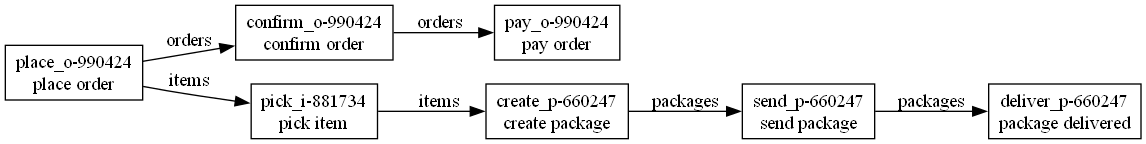

In [9]:
output_path = save_instance_graph(
    graph,
    GRAPH_OUTPUT_PATH,
)

print("Grafo salvato in:", output_path)

display(
    Image(
        filename=str(output_path),
    )
)

## Conclusioni

Il blocco ha costruito un Instance Graph a partire da una process
execution estratta dal dataset OCEL 2.0 reale Order Management.

Per l'ordine `o-990424` sono stati ottenuti:

- 7 eventi;
- 6 archi causali;
- un grafo diretto aciclico;
- un grafo già transitivamente ridotto;
- 8 coppie di eventi incomparabili.

Il risultato evita di trasformare automaticamente l'ordine
cronologico in causalità. Per questo il pagamento tardivo resta
incomparabile con gli eventi del ramo logistico.

### Limiti

Il risultato non completa ancora il metodo richiesto dal progetto.

Le sei causal relations sono state definite manualmente e poi
applicate agli eventi che condividono oggetti compatibili. Non sono
state ricavate automaticamente dall'OCPN scoperta nel Blocco 3.

Inoltre, questo blocco non dimostra ancora mediante conformance
checking object-centric che la process execution selezionata abbia
fitness pari a 1.

Il blocco successivo dovrà quindi studiare come ottenere o validare le
relazioni causali usando il modello object-centric, riducendo la
dipendenza da ipotesi inserite manualmente.